In [1]:
import importlib

import qnmfits
importlib.reload(qnmfits)
import sxs

import numpy as np
import matplotlib.pyplot as plt

In [2]:
def wrap_phase(phi):
    """Wrap phase to (-pi, pi]."""
    return np.angle(np.exp(1j * phi))


def apc_phase_33_22(A22, A33):
    """
    APC phase combination:
        Delta_phi = 3/2 phi_22 - phi_33
    """
    phi22 = np.angle(A22)
    phi33 = np.angle(A33)

    return wrap_phase(1.5 * phi22 - phi33)

In [8]:
h.metadata['remnant_dimensionless_spin']

[9.13765586478e-10, -3.77301001538e-10, 0.608209224498]

/Users/xisco/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Simulation: SXS:BBH:0004
Mf = 0.957720872946
chi_f = 0.608209224498


/var/folders/jk/_y_k1ymd0v96sbdtr34fy2hm0000gn/T/ipykernel_98142/298721992.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-0.01, 0.01)


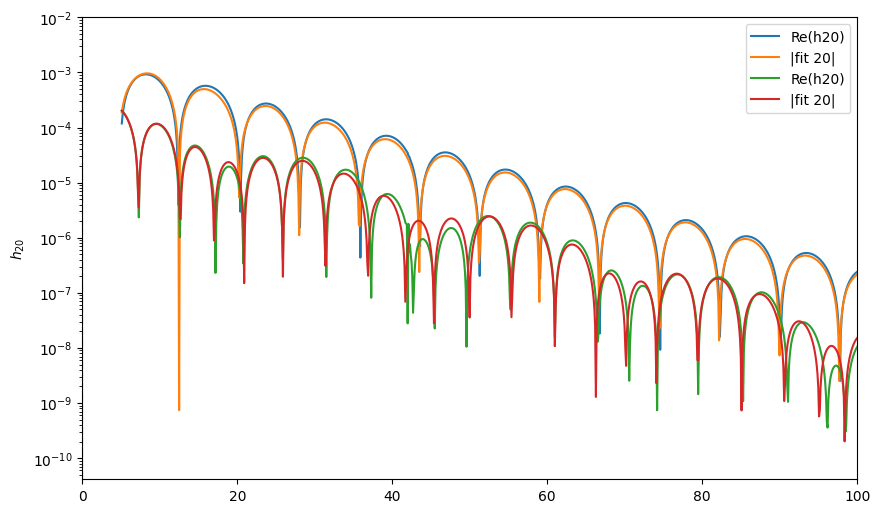

In [3]:
# Simulación de prueba
sim_name = 'SXS:BBH:0004'

# Tiempo de referencia (t_peak + 10)
t_ref = 10.

sim = sxs.load(sim_name, ignore_deprecation=True)
h = sim.Psi4

Mf = sim.metadata.remnant_mass
chif = np.array(h.metadata['remnant_dimensionless_spin'])
chif_mag = np.linalg.norm(chif)

t0 = 0
t_ref = 10

print("Simulation:", sim_name)
print("Mf =", Mf)
print("chi_f =", chif_mag)
# =========================
# WAVEFORM
# =========================
#h = qnmfits.utils.sxs_to_scri_WaveformModes(sim.h)

# Correct the offset
for ell, m in h.LM:
    k = h.index(ell, m)

    mode = h.data[:, k].copy()
    mode -= mode[-1]   # or use np.mean(mode[-N_offset:])

    h.data[:, k] = mode
    
h22 = h.data[:, h.index(2,2)]

h20 = h.data[:, h.index(2,0)]
h30 = h.data[:, h.index(3,0)]

# centrar en t_peak del 22
t_peak = h.t[np.argmax(h20)]
h.t -= t_peak

#qnms_20 = [(2,0,n,1) for n in range(1)]  
#qnms_30 = [(3,0,n,1) for n in range(7+1)]
qnms_20 = [(2,0,n,s) for n in range(1) for s in (+1, -1)]
qnms_30 = [(3,0,n,s) for n in range(4) for s in (+1, -1)]

t0 = 5

h20 = h.data[:, h.index(2,0)]
fit_20 = qnmfits.ringdown_fit(
    h.time, 
    h20, 
    modes=[(2,0,0,1),(2,0,0,-1),(2,2,0,1,2,-2,0,1),(2,2,0,-1,2,-2,0,-1)], 
    Mf=Mf,
    chif=chif_mag,
    t0=t0
)

h30 = h.data[:, h.index(3,0)]
fit_30 = qnmfits.ringdown_fit(
    h.time, 
    h30, 
    modes=[(3,0,0,1),(3,0,0,-1),(2,0,0,1), (2,0,0,-1),(2,2,0,1,2,-2,0,1),(2,2,0,-1,2,-2,0,-1)], 
    Mf=Mf,
    chif=chif_mag,
    t0=t0
)


plt.figure(figsize=(10,6))

#fig, axes = plt.subplots(2, 1, figsize=(8,6), sharex=True)
# =========================
# MODO (2,2)
# =========================
plt.plot(fit_20['model_times'], np.abs(fit_20['data']), label='Re(h20)')
plt.plot(fit_20['model_times'], np.abs(fit_20['model']), label='|fit 20|')
plt.plot(fit_30['model_times'], np.abs(fit_30['data']), label='Re(h20)')
plt.plot(fit_30['model_times'], np.abs(fit_30['model']), label='|fit 20|')
plt.yscale('log')
plt.axvline(0, ls='--', c='k')
plt.ylabel(r'$h_{20}$')
plt.xlim(0, 100)
plt.ylim(-0.01, 0.01)

plt.legend()
plt.show()


In [4]:
C20 = fit_20["C"]

A200p = C20[0]
A200m = C20[1]
A22x2m2_p = C20[2]
A22x2m2_m = C20[3]

C30 = fit_30["C"]

A300p = C30[0]
A300m = C30[1]

A200_leak_p = C30[2]
A200_leak_m = C30[3]
R_300_200 = np.abs(A300p) / np.abs(A200p)


modes_22 = [(2,2,0,1)]
modes_33 = [(3,3,0,1)]

A20 = fit_20["C"][0]
A30 = fit_30["C"][0]

Delta_phi = apc_phase_33_22(A20, A30)

print('Amplitude Ratio =',R_300_200)
print("Delta phi =", np.mod(Delta_phi,np.pi))

Amplitude Ratio = 0.11609281138651688
Delta phi = 2.486825156527547


In [5]:
sim_list = [
"SXS:BBH:0004","SXS:BBH:0005","SXS:BBH:0007","SXS:BBH:0013",
"SXS:BBH:0016","SXS:BBH:0019","SXS:BBH:0025","SXS:BBH:0030",
"SXS:BBH:0036","SXS:BBH:0045","SXS:BBH:0046","SXS:BBH:0047",
"SXS:BBH:0056","SXS:BBH:0060","SXS:BBH:0061","SXS:BBH:0063",
"SXS:BBH:0064","SXS:BBH:0065","SXS:BBH:0148","SXS:BBH:0149",
"SXS:BBH:0150","SXS:BBH:0151","SXS:BBH:0152","SXS:BBH:0153",
"SXS:BBH:0154","SXS:BBH:0155","SXS:BBH:0156","SXS:BBH:0157",
"SXS:BBH:0158","SXS:BBH:0159","SXS:BBH:0160","SXS:BBH:0166",
"SXS:BBH:0167","SXS:BBH:0169","SXS:BBH:0170","SXS:BBH:0172",
"SXS:BBH:0174","SXS:BBH:0177","SXS:BBH:0178","SXS:BBH:0180",
"SXS:BBH:0202","SXS:BBH:0203","SXS:BBH:0204","SXS:BBH:0205",
"SXS:BBH:0206","SXS:BBH:0207","SXS:BBH:0306","SXS:BBH:0290",
"SXS:BBH:0291","SXS:BBH:0289","SXS:BBH:0285","SXS:BBH:0261",
"SXS:BBH:0293","SXS:BBH:0280","SXS:BBH:0257","SXS:BBH:0279",
"SXS:BBH:0274","SXS:BBH:0258","SXS:BBH:0248","SXS:BBH:0232",
"SXS:BBH:0229","SXS:BBH:0231","SXS:BBH:0239","SXS:BBH:0252",
"SXS:BBH:0219","SXS:BBH:0211","SXS:BBH:0233","SXS:BBH:0243",
"SXS:BBH:0214","SXS:BBH:0209","SXS:BBH:0226","SXS:BBH:0286",
"SXS:BBH:0253","SXS:BBH:0267","SXS:BBH:0218","SXS:BBH:0238",
"SXS:BBH:0288","SXS:BBH:0287","SXS:BBH:0283","SXS:BBH:0282",
"SXS:BBH:0281","SXS:BBH:0277","SXS:BBH:0284","SXS:BBH:0278",
"SXS:BBH:0256","SXS:BBH:0230","SXS:BBH:0255","SXS:BBH:0276",
"SXS:BBH:0251","SXS:BBH:0250","SXS:BBH:0271","SXS:BBH:0249",
"SXS:BBH:0275","SXS:BBH:0254","SXS:BBH:0269","SXS:BBH:0225",
"SXS:BBH:0270","SXS:BBH:0245","SXS:BBH:0242","SXS:BBH:0223",
"SXS:BBH:0241","SXS:BBH:0240","SXS:BBH:0222","SXS:BBH:0228",
"SXS:BBH:0247","SXS:BBH:0263","SXS:BBH:0266","SXS:BBH:0227",
"SXS:BBH:0221","SXS:BBH:0237","SXS:BBH:0259","SXS:BBH:0574",
"SXS:BBH:0244","SXS:BBH:0217","SXS:BBH:0215","SXS:BBH:0262",
"SXS:BBH:0213","SXS:BBH:0265","SXS:BBH:0264","SXS:BBH:0224",
"SXS:BBH:0236","SXS:BBH:0216","SXS:BBH:0235","SXS:BBH:0220",
"SXS:BBH:0212","SXS:BBH:0303","SXS:BBH:0300","SXS:BBH:0299",
"SXS:BBH:0298","SXS:BBH:0297","SXS:BBH:0296","SXS:BBH:0295",
"SXS:BBH:0292","SXS:BBH:0268","SXS:BBH:0234","SXS:BBH:0273",
"SXS:BBH:0210","SXS:BBH:0260","SXS:BBH:0302","SXS:BBH:0301",
"SXS:BBH:0272","SXS:BBH:0246","SXS:BBH:0610","SXS:BBH:0611",
"SXS:BBH:0612","SXS:BBH:0613","SXS:BBH:0614","SXS:BBH:0615",
"SXS:BBH:0616","SXS:BBH:0617","SXS:BBH:0618","SXS:BBH:0619",
"SXS:BBH:0620","SXS:BBH:0621","SXS:BBH:0622"
]

In [9]:
sim_list = ["SXS:BBH:0004","SXS:BBH:0005","SXS:BBH:0007","SXS:BBH:0013",
"SXS:BBH:0016","SXS:BBH:0019"]

In [17]:
results = []
mm_ref = 0
mm_hm = 0

for sim_name in sim_list:
    try:
        # =========================
        # LOAD
        # =========================

        sim = sxs.load(sim_name, ignore_deprecation=True)
        h = sim.Psi4
        
        Mf = sim.metadata.remnant_mass
        chif = np.array(h.metadata['remnant_dimensionless_spin'])
        chif_mag = np.linalg.norm(chif)
        
        t0 = 0
        t_ref = 10

        # =========================
        # WAVEFORM
        # =========================
        # Correct the offset
        for ell, m in h.LM:
            k = h.index(ell, m)
        
            mode = h.data[:, k].copy()
            mode -= mode[-1]   # or use np.mean(mode[-N_offset:])
        
            h.data[:, k] = mode
            
        h20 = h.data[:, h.index(2,0)]
        h30 = h.data[:, h.index(3,0)]
        
        # centrar en t_peak del 22
        t_peak = h.t[np.argmax(h20)]
        h.t -= t_peak

        t0 = 5

        h20 = h.data[:, h.index(2,0)]
        fit_20 = qnmfits.ringdown_fit(
            h.time, 
            h20, 
            modes=[(2,0,0,1),(2,0,0,-1),(2,2,0,1,2,-2,0,1),(2,2,0,-1,2,-2,0,-1)], 
            Mf=Mf,
            chif=chif_mag,
            t0=t0
        )
        
        h30 = h.data[:, h.index(3,0)]
        fit_30 = qnmfits.ringdown_fit(
            h.time, 
            h30, 
            modes=[(3,0,0,1),(3,0,0,-1),(2,0,0,1), (2,0,0,-1),(2,2,0,1,2,-2,0,1),(2,2,0,-1,2,-2,0,-1)], 
            Mf=Mf,
            chif=chif_mag,
            t0=t0
        )
        C20 = fit_20["C"]
        
        A200p = C20[0]
        A200m = C20[1]
        A22x2m2_p = C20[2]
        A22x2m2_m = C20[3]
        
        C30 = fit_30["C"]
        
        A300p = C30[0]
        A300m = C30[1]
        
        A200_leak_p = C30[2]
        A200_leak_m = C30[3]
        R_300_200 = np.abs(A300p) / np.abs(A200p)
        ratio_h = R_300_200
                
        modes_22 = [(2,2,0,1)]
        modes_33 = [(3,3,0,1)]
        
        A20 = fit_20["C"][0]
        A30 = fit_30["C"][0]
        
        Delta_phi = apc_phase_33_22(A20, A30)
                # fundamentales

        delta_phi_A = np.mod(Delta_phi, np.pi)

        # =========================
        # GUARDAR
        # =========================
        results.append({
            "chi_f": chif_mag,
            "ratio_h": ratio_h,
            "delta_phi_h": delta_phi_A,
        })

        print(f"{sim_name}: OK")

    except Exception as e:
        print(f"{sim_name}: ERROR ({e})")


# =======================================
# EXTRAER ARRAYS
# =======================================
chi = np.array([r["chi_f"] for r in results])

ratio_h = np.array([r["ratio_h"] for r in results])

delta_phi_h = np.array([r["delta_phi_h"] for r in results])

SXS:BBH:0004: OK
SXS:BBH:0005: OK
SXS:BBH:0007: OK
SXS:BBH:0013: OK
SXS:BBH:0016: OK
SXS:BBH:0019: OK


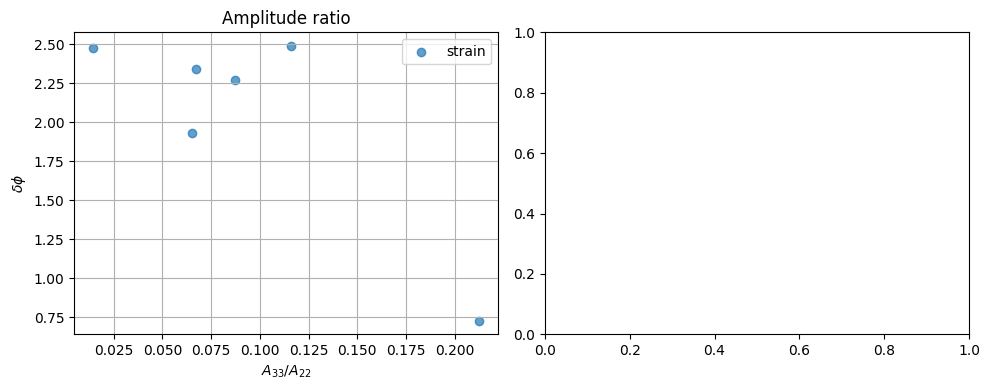

In [21]:
# =======================================
# FIGURAS
# =======================================
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# ---- Ratio ----
axes[0].scatter(ratio_h,delta_phi_h, label='strain', alpha=0.7)
#axes[0].scatter(chi, ratio_A, label='QNM fit', alpha=0.7)

axes[0].set_ylabel(r'$\delta \phi$')
axes[0].set_xlabel(r'$A_{33}/A_{22}$')
axes[0].set_title('Amplitude ratio')
axes[0].legend()
axes[0].grid()
plt.tight_layout()
plt.show()

NameError: name 'ratio_A' is not defined

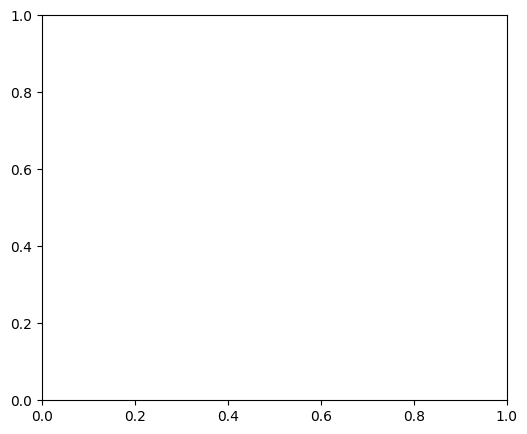

In [5]:
# =======================================
# FIGURA: delta_phi vs ratio
# =======================================
fig, ax = plt.subplots(figsize=(6,5))

# ---- STRAIN ----
#ax.scatter(
#    ratio_h,
#    -delta_phi_h +np.pi,
#    label='strain',
#    alpha=0.7
#)

# ---- QNM FIT ----
ax.scatter(
    ratio_A,
    -delta_phi_A+np.pi,
    label='QNM fit',
    alpha=0.7
)

ax.set_xlabel(r'$A_{33}/A_{22}$')
ax.set_ylabel(r'$\delta \phi_{330}$')

ax.set_title(r'$\delta \phi_{330}$ vs $A_{33}/A_{22}$')

ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# other 2

Mf = 0.952032939704
chi_f = 0.6920851868180025


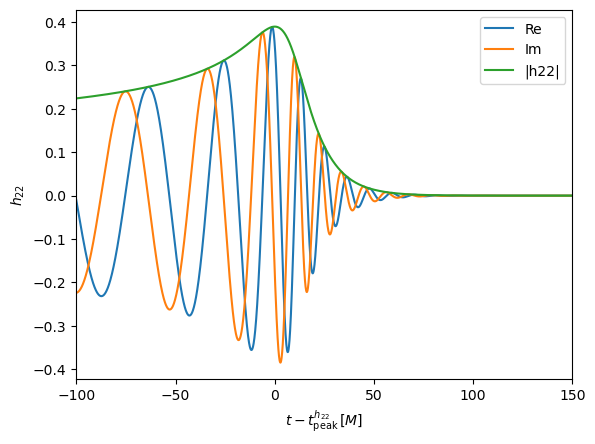

Mismatch: 0.00022010014727902316


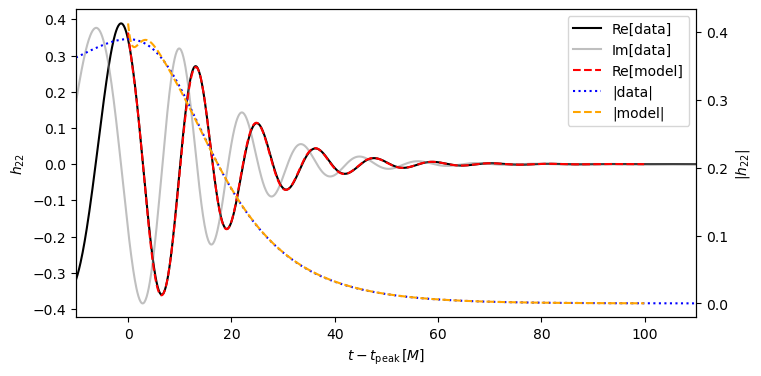

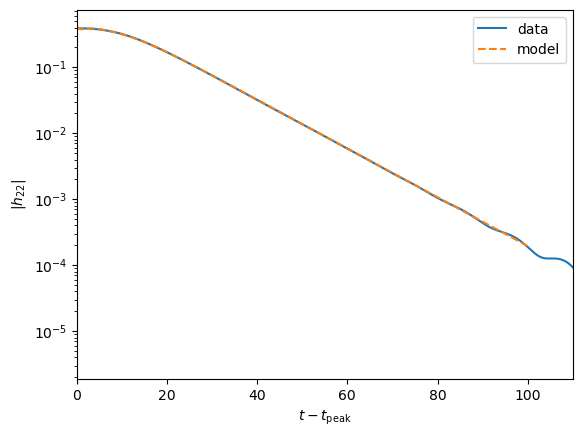

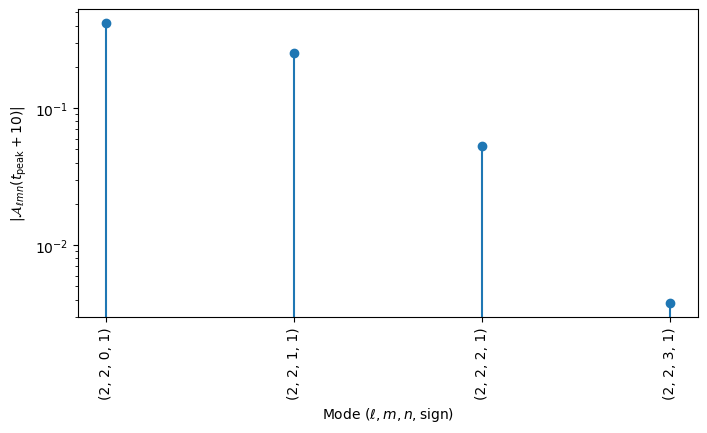


Amplitudes ordenadas:
(2, 2, 0, 1): 4.176e-01
(2, 2, 1, 1): 2.523e-01
(2, 2, 2, 1): 5.320e-02
(2, 2, 3, 1): 3.780e-03
Mismatch: 3.041426973604544e-07

|A_lmn| y Arg(A_lmn) en t_peak + 10:

(2, 2, 0, 1): |A| = 4.141527e-01, Arg(A) = 2.201128 rad
(2, 2, 1, 1): |A| = 3.192112e-01, Arg(A) = 0.177957 rad
(2, 2, 2, 1): |A| = 1.457421e-01, Arg(A) = -2.336661 rad
(2, 2, 3, 1): |A| = 4.793191e-02, Arg(A) = 1.112729 rad
(2, 2, 4, 1): |A| = 1.147686e-02, Arg(A) = -1.922784 rad
(2, 2, 5, 1): |A| = 1.798710e-03, Arg(A) = 1.114680 rad
(2, 2, 6, 1): |A| = 1.341915e-04, Arg(A) = -2.293824 rad
(2, 2, 7, 1): |A| = 3.645037e-06, Arg(A) = 0.653629 rad


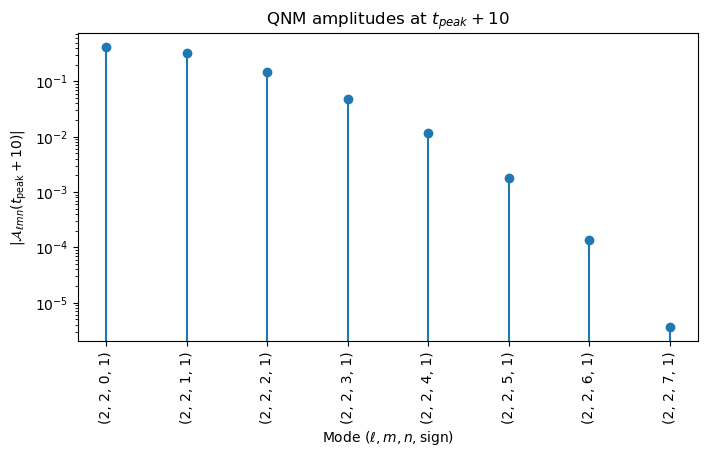

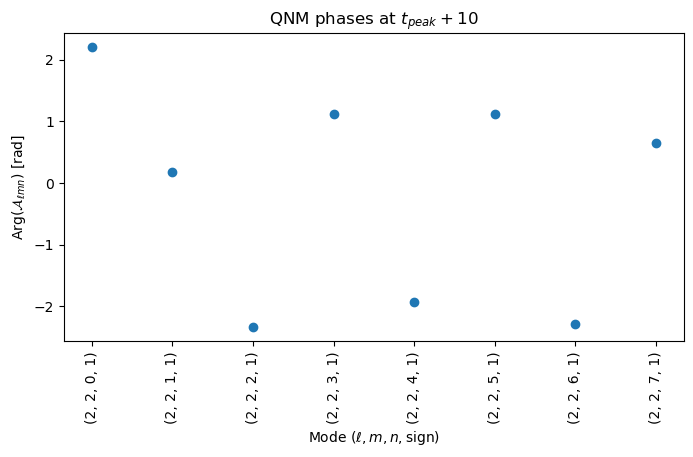

In [30]:
# =======================================
# 1. Cargar simulación
# =======================================
sim = sxs.load('SXS:BBH:0305v1.5', extrapolation='N2')

Mf = sim.metadata.remnant_mass
chif = sim.metadata.remnant_dimensionless_spin
chif_mag = np.linalg.norm(chif)

print("Mf =", Mf)
print("chi_f =", chif_mag)

# =======================================
# 2. Preparar waveform
# =======================================
h = qnmfits.utils.sxs_to_scri_WaveformModes(sim.h)
h22 = h.data[:, h.index(2,2)]

# Centrar en t_peak del modo 22
h.t -= h.t[np.argmax(np.abs(h22))]

# =======================================
# 3. Plot señal
# =======================================
fig, ax = plt.subplots()

ax.plot(h.t, np.real(h22), label='Re')
ax.plot(h.t, np.imag(h22), label='Im')
ax.plot(h.t, np.abs(h22), label='|h22|')

ax.set_xlabel(r'$t - t_\mathrm{peak}^{h_{22}}\,[M]$')
ax.set_ylabel(r'$h_{22}$')

ax.legend()
ax.set_xlim(-100,150)

plt.show()

# -------------------------------
# 1. Definición de modos QNM
# -------------------------------
qnms = [(2,2,n,1) for n in range(4)]  # n=0..3 (más estable que 8)

# Modos esféricos a ajustar
spherical_modes = [(2,2)]

# -------------------------------
# 2. Parámetros del fit
# -------------------------------
t0 = 0.          # inicio del fit (datos usados)
t_ref = 10.      # amplitudes evaluadas en t_peak + 10

# -------------------------------
# 3. Ejecutar fit
# -------------------------------
best_fit = qnmfits.fit(
    data=h,
    chif=chif_mag,
    Mf=Mf,
    qnms=qnms,
    spherical_modes=spherical_modes,
    t0=t0,
    t_ref=t_ref
)

print("Mismatch:", best_fit["mismatch"])

# -------------------------------
# 4. Extraer modo (2,2)
# -------------------------------
h22 = h.data[:, h.index(2,2)]

h_best_fit = best_fit['model']
h22_best_fit = h_best_fit.data[:, h_best_fit.index(2,2)]

# -------------------------------
# 5. Plot: Re/Im + |h|
# -------------------------------
fig, ax = plt.subplots(figsize=(8,4))

# Datos
ax.plot(h.t, np.real(h22), c='k', label='Re[data]')
ax.plot(h.t, np.imag(h22), c='gray', alpha=0.5, label='Im[data]')

# Modelo
ax.plot(
    h_best_fit.t,
    np.real(h22_best_fit),
    c='r',
    ls='--',
    label='Re[model]'
)

# Módulo (eje secundario)
ax2 = ax.twinx()
ax2.plot(h.t, np.abs(h22), 'b:', label='|data|')
ax2.plot(h_best_fit.t, np.abs(h22_best_fit), 'orange', ls='--', label='|model|')

ax.set_xlabel(r'$t - t_\mathrm{peak}\,[M]$')
ax.set_ylabel(r'$h_{22}$')
ax2.set_ylabel(r'$|h_{22}|$')

# Leyenda combinada
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2)

ax.set_xlim(-10, 110)

plt.show()

# -------------------------------
# 6. Plot log(|h|)
# -------------------------------
fig, ax = plt.subplots()

ax.plot(h.t, np.abs(h22), label='data')
ax.plot(h_best_fit.t, np.abs(h22_best_fit), '--', label='model')

ax.set_yscale('log')
ax.set_xlim(0, 110)

ax.set_xlabel(r'$t - t_\mathrm{peak}$')
ax.set_ylabel(r'$|h_{22}|$')

ax.legend()
plt.show()

# -------------------------------
# 7. Plot amplitudes QNM
# -------------------------------
amps_dict = best_fit['amplitudes']

amplitudes = [abs(amps_dict[label]) for label in qnms]
labels = [f"{l,m,n,s}" for (l,m,n,s) in qnms]

x = np.arange(len(amplitudes))

fig, ax = plt.subplots(figsize=(8,4))
ax.stem(x, amplitudes, basefmt=" ")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)

ax.set_yscale('log')

ax.set_xlabel(r'Mode $(\ell,m,n,\mathrm{sign})$')
ax.set_ylabel(r'$|\mathcal{A}_{\ell mn}(t_\mathrm{peak}+10)|$')

plt.show()

# -------------------------------
# 8. Mostrar amplitudes ordenadas
# -------------------------------
print("\nAmplitudes ordenadas:")
sorted_modes = sorted(amps_dict.items(), key=lambda x: abs(x[1]), reverse=True)

for mode, amp in sorted_modes:
    print(f"{mode}: {abs(amp):.3e}")


# ---------------------------------------
# 1. Modos QNM a incluir
# ---------------------------------------
qnms = [(2,2,n,1) for n in range(7+1)]  # n=0..3 (estable)

spherical_modes = [(2,2)]

# ---------------------------------------
# 2. Parámetros del fit
# ---------------------------------------
t0 = 0.        # inicio del fit (t_peak)
t_ref = 10.    # amplitudes en t_peak + 10

# ---------------------------------------
# 3. Ejecutar fit
# ---------------------------------------
best_fit = qnmfits.fit(
    data=h,
    chif=chif_mag,
    Mf=Mf,
    qnms=qnms,
    spherical_modes=spherical_modes,
    t0=t0,
    t_ref=t_ref
)

print("Mismatch:", best_fit["mismatch"])

# ---------------------------------------
# 4. Extraer amplitudes |A|
# ---------------------------------------
amps = best_fit['amplitudes']

print("\n|A_lmn| y Arg(A_lmn) en t_peak + 10:\n")
for mode in qnms:
    A = amps[mode]
    print(f"{mode}: |A| = {abs(A):.6e}, Arg(A) = {np.angle(A):.6f} rad")

# ---------------------------------------
# 5. Plot de |A|
# ---------------------------------------
amplitudes = [abs(amps[label]) for label in qnms]
phases = [np.angle(amps[label]) for label in qnms]
labels = [f"{l,m,n,s}" for (l,m,n,s) in qnms]

x = np.arange(len(amplitudes))

fig, ax = plt.subplots(figsize=(8,4))

ax.stem(x, amplitudes, basefmt=" ")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)

ax.set_yscale('log')

ax.set_xlabel(r'Mode $(\ell,m,n,\mathrm{sign})$')
ax.set_ylabel(r'$|\mathcal{A}_{\ell mn}(t_\mathrm{peak}+10)|$')

ax.set_title('QNM amplitudes at $t_{peak} + 10$')

plt.show()

fig, ax = plt.subplots(figsize=(8,4))

ax.scatter(x, phases)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)

ax.set_xlabel(r'Mode $(\ell,m,n,\mathrm{sign})$')
ax.set_ylabel(r'$\mathrm{Arg}(\mathcal{A}_{\ell mn})$ [rad]')
ax.set_title('QNM phases at $t_{peak}+10$')

plt.show()


Mismatch: 3.041426973604544e-07

|A_lmn| y Arg(A_lmn) en t_peak + 10:

(2, 2, 0, 1): |A| = 4.141527e-01, Arg(A) = 2.201128 rad
(2, 2, 1, 1): |A| = 3.192112e-01, Arg(A) = 0.177957 rad
(2, 2, 2, 1): |A| = 1.457421e-01, Arg(A) = -2.336661 rad
(2, 2, 3, 1): |A| = 4.793191e-02, Arg(A) = 1.112729 rad
(2, 2, 4, 1): |A| = 1.147686e-02, Arg(A) = -1.922784 rad
(2, 2, 5, 1): |A| = 1.798710e-03, Arg(A) = 1.114680 rad
(2, 2, 6, 1): |A| = 1.341915e-04, Arg(A) = -2.293824 rad
(2, 2, 7, 1): |A| = 3.645037e-06, Arg(A) = 0.653629 rad


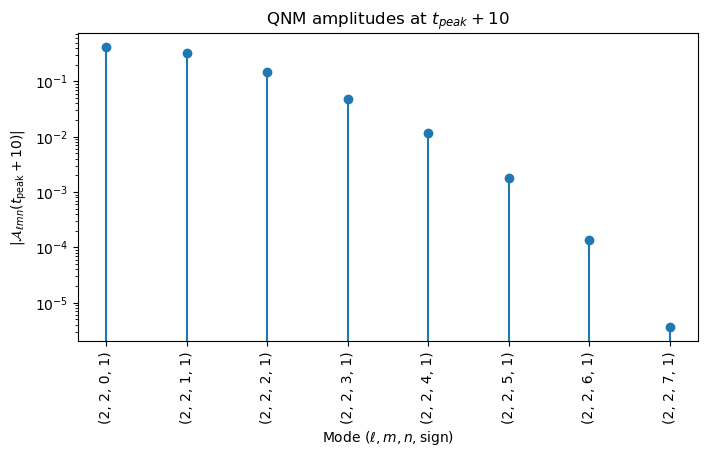

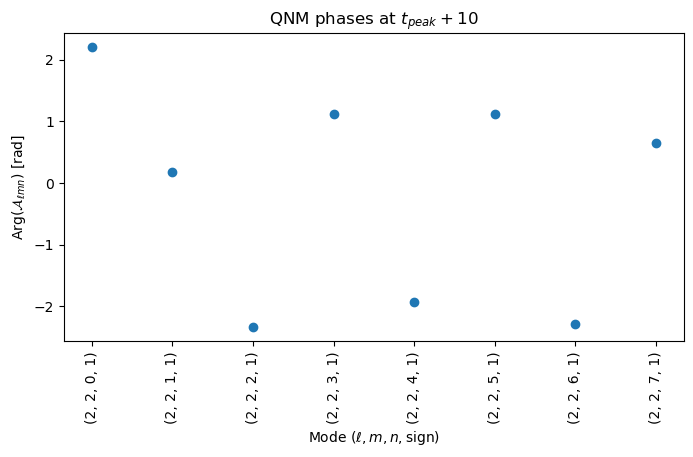

In [26]:
sim_list = [
"SXS:BBH:0004","SXS:BBH:0005","SXS:BBH:0007","SXS:BBH:0013",
"SXS:BBH:0016","SXS:BBH:0019","SXS:BBH:0025","SXS:BBH:0030",
"SXS:BBH:0036","SXS:BBH:0045","SXS:BBH:0046","SXS:BBH:0047",
"SXS:BBH:0056","SXS:BBH:0060","SXS:BBH:0061","SXS:BBH:0063",
"SXS:BBH:0064","SXS:BBH:0065","SXS:BBH:0148","SXS:BBH:0149",
"SXS:BBH:0150","SXS:BBH:0151","SXS:BBH:0152","SXS:BBH:0153",
"SXS:BBH:0154","SXS:BBH:0155","SXS:BBH:0156","SXS:BBH:0157",
"SXS:BBH:0158","SXS:BBH:0159","SXS:BBH:0160","SXS:BBH:0166",
"SXS:BBH:0167","SXS:BBH:0169","SXS:BBH:0170","SXS:BBH:0172",
"SXS:BBH:0174","SXS:BBH:0177","SXS:BBH:0178","SXS:BBH:0180",
"SXS:BBH:0202","SXS:BBH:0203","SXS:BBH:0204","SXS:BBH:0205",
"SXS:BBH:0206","SXS:BBH:0207","SXS:BBH:0306","SXS:BBH:0290",
"SXS:BBH:0291","SXS:BBH:0289","SXS:BBH:0285","SXS:BBH:0261",
"SXS:BBH:0293","SXS:BBH:0280","SXS:BBH:0257","SXS:BBH:0279",
"SXS:BBH:0274","SXS:BBH:0258","SXS:BBH:0248","SXS:BBH:0232",
"SXS:BBH:0229","SXS:BBH:0231","SXS:BBH:0239","SXS:BBH:0252",
"SXS:BBH:0219","SXS:BBH:0211","SXS:BBH:0233","SXS:BBH:0243",
"SXS:BBH:0214","SXS:BBH:0209","SXS:BBH:0226","SXS:BBH:0286",
"SXS:BBH:0253","SXS:BBH:0267","SXS:BBH:0218","SXS:BBH:0238",
"SXS:BBH:0288","SXS:BBH:0287","SXS:BBH:0283","SXS:BBH:0282",
"SXS:BBH:0281","SXS:BBH:0277","SXS:BBH:0284","SXS:BBH:0278",
"SXS:BBH:0256","SXS:BBH:0230","SXS:BBH:0255","SXS:BBH:0276",
"SXS:BBH:0251","SXS:BBH:0250","SXS:BBH:0271","SXS:BBH:0249",
"SXS:BBH:0275","SXS:BBH:0254","SXS:BBH:0269","SXS:BBH:0225",
"SXS:BBH:0270","SXS:BBH:0245","SXS:BBH:0242","SXS:BBH:0223",
"SXS:BBH:0241","SXS:BBH:0240","SXS:BBH:0222","SXS:BBH:0228",
"SXS:BBH:0247","SXS:BBH:0263","SXS:BBH:0266","SXS:BBH:0227",
"SXS:BBH:0221","SXS:BBH:0237","SXS:BBH:0259","SXS:BBH:0574",
"SXS:BBH:0244","SXS:BBH:0217","SXS:BBH:0215","SXS:BBH:0262",
"SXS:BBH:0213","SXS:BBH:0265","SXS:BBH:0264","SXS:BBH:0224",
"SXS:BBH:0236","SXS:BBH:0216","SXS:BBH:0235","SXS:BBH:0220",
"SXS:BBH:0212","SXS:BBH:0303","SXS:BBH:0300","SXS:BBH:0299",
"SXS:BBH:0298","SXS:BBH:0297","SXS:BBH:0296","SXS:BBH:0295",
"SXS:BBH:0292","SXS:BBH:0268","SXS:BBH:0234","SXS:BBH:0273",
"SXS:BBH:0210","SXS:BBH:0260","SXS:BBH:0302","SXS:BBH:0301",
"SXS:BBH:0272","SXS:BBH:0246","SXS:BBH:0610","SXS:BBH:0611",
"SXS:BBH:0612","SXS:BBH:0613","SXS:BBH:0614","SXS:BBH:0615",
"SXS:BBH:0616","SXS:BBH:0617","SXS:BBH:0618","SXS:BBH:0619",
"SXS:BBH:0620","SXS:BBH:0621","SXS:BBH:0622"
]

spin_dict = {}

for sim_name in sim_list:
    try:
        # Cargar simulación (solo metadata se cachea)
        sim = sxs.load(sim_name, ignore_deprecation=True)
        #sim = sxs.load(sim_name, auto_supersede=True)
        
        chif = sim.metadata.remnant_dimensionless_spin
        chif_mag = np.linalg.norm(chif)
        
        spin_dict[sim_name] = chif_mag
        
        print(f"{sim_name}: chi_f = {chif_mag:.4f}")
    
    except Exception as e:
        print(f"{sim_name}: ERROR ({e})")


SXS:BBH:0004: chi_f = 0.6082
SXS:BBH:0005: chi_f = 0.7607
SXS:BBH:0007: chi_f = 0.6641
SXS:BBH:0013: chi_f = 0.7814
SXS:BBH:0016: chi_f = 0.5403
SXS:BBH:0019: chi_f = 0.5868
SXS:BBH:0025: chi_f = 0.7384
SXS:BBH:0030: chi_f = 0.5406
SXS:BBH:0036: chi_f = 0.3163
SXS:BBH:0045: chi_f = 0.7410
SXS:BBH:0046: chi_f = 0.2993
SXS:BBH:0047: chi_f = 0.7686
SXS:BBH:0056: chi_f = 0.4166
SXS:BBH:0060: chi_f = 0.1166
SXS:BBH:0061: chi_f = 0.7065
SXS:BBH:0063: chi_f = 0.3067
SXS:BBH:0064: chi_f = 0.0526
SXS:BBH:0065: chi_f = 0.6574
SXS:BBH:0148: chi_f = 0.5478
SXS:BBH:0149: chi_f = 0.6242
SXS:BBH:0150: chi_f = 0.7464
SXS:BBH:0151: chi_f = 0.4942
SXS:BBH:0152: chi_f = 0.8578
SXS:BBH:0153: chi_f = 0.9191
SXS:BBH:0154: chi_f = 0.4269
SXS:BBH:0155: chi_f = 0.9075
SXS:BBH:0156: chi_f = 0.3757
SXS:BBH:0157: chi_f = 0.9409
SXS:BBH:0158: chi_f = 0.9450
SXS:BBH:0159: chi_f = 0.3927
SXS:BBH:0160: chi_f = 0.9302
SXS:BBH:0166: chi_f = 0.3725
SXS:BBH:0167: chi_f = 0.4716
SXS:BBH:0169: chi_f = 0.6234
SXS:BBH:0170: 

=== Loading simulations ===
SXS:BBH:0004: q=1.00, chi_f=0.6082
SXS:BBH:0005: q=1.00, chi_f=0.7607
SXS:BBH:0007: q=1.50, chi_f=0.6641
SXS:BBH:0013: q=1.50, chi_f=0.7814
SXS:BBH:0016: q=1.50, chi_f=0.5403
SXS:BBH:0019: q=1.50, chi_f=0.5868
SXS:BBH:0025: q=1.50, chi_f=0.7384
SXS:BBH:0030: q=3.00, chi_f=0.5406
SXS:BBH:0036: q=3.00, chi_f=0.3163
SXS:BBH:0045: q=3.00, chi_f=0.7410
SXS:BBH:0046: q=3.00, chi_f=0.2993
SXS:BBH:0047: q=3.00, chi_f=0.7686
SXS:BBH:0056: q=5.00, chi_f=0.4166
SXS:BBH:0060: q=5.00, chi_f=0.1166
SXS:BBH:0061: q=5.00, chi_f=0.7065
SXS:BBH:0063: q=8.00, chi_f=0.3067
SXS:BBH:0064: q=8.00, chi_f=0.0526
SXS:BBH:0065: q=8.00, chi_f=0.6574
SXS:BBH:0148: q=1.00, chi_f=0.5478
SXS:BBH:0149: q=1.00, chi_f=0.6242
SXS:BBH:0150: q=1.00, chi_f=0.7464
SXS:BBH:0151: q=1.00, chi_f=0.4942
SXS:BBH:0152: q=1.00, chi_f=0.8578
SXS:BBH:0153: q=1.00, chi_f=0.9191
SXS:BBH:0154: q=1.00, chi_f=0.4269
SXS:BBH:0155: q=1.00, chi_f=0.9075
SXS:BBH:0156: q=1.00, chi_f=0.3757
SXS:BBH:0157: q=1.00, chi_f

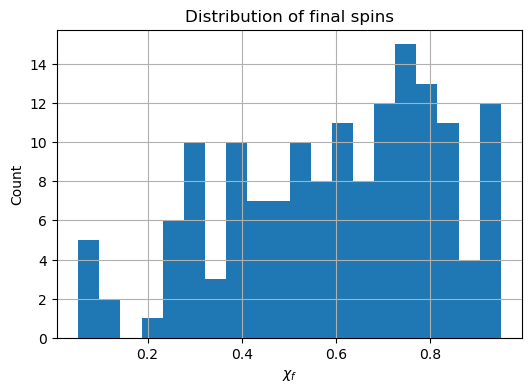

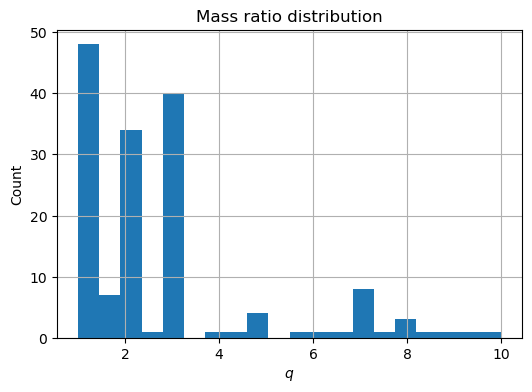

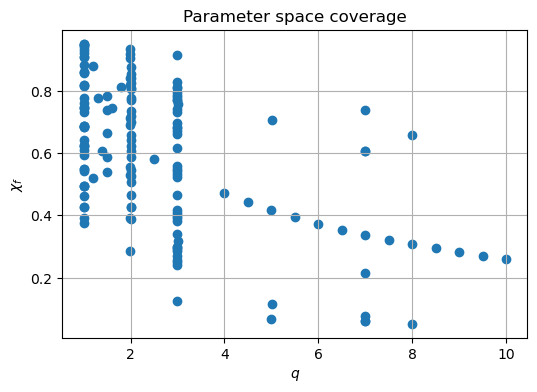

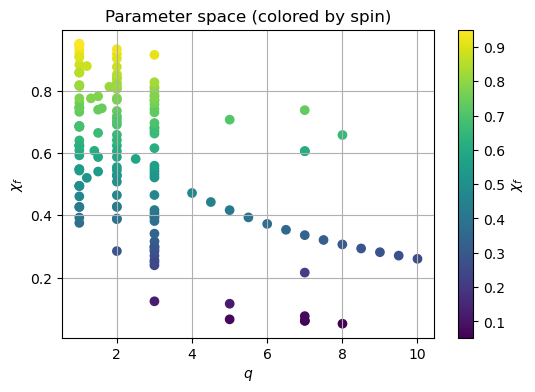

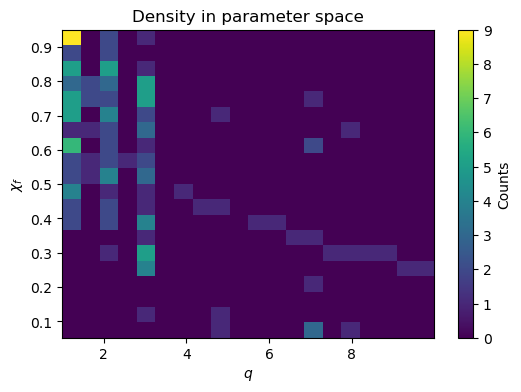

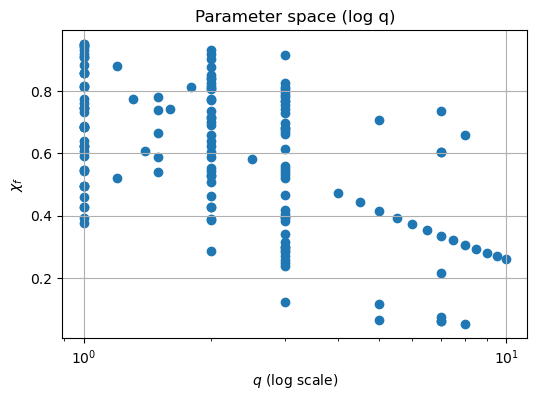


=== Spin distribution ===
Low spin (<0.3): 21
Mid spin (0.3–0.7): 75
High spin (>0.7): 59

=== Extreme spins ===
SXS:BBH:0064: q=8.00, chi_f=0.0526
SXS:BBH:0205: q=7.00, chi_f=0.0620
SXS:BBH:0206: q=7.00, chi_f=0.0619
SXS:BBH:0207: q=7.00, chi_f=0.0770
SXS:BBH:0620: q=5.00, chi_f=0.0667

=== Sorted by spin ===
SXS:BBH:0064: q=8.00, chi_f=0.0526
SXS:BBH:0206: q=7.00, chi_f=0.0619
SXS:BBH:0205: q=7.00, chi_f=0.0620
SXS:BBH:0620: q=5.00, chi_f=0.0667
SXS:BBH:0207: q=7.00, chi_f=0.0770
SXS:BBH:0060: q=5.00, chi_f=0.1166
SXS:BBH:0260: q=3.00, chi_f=0.1245
SXS:BBH:0621: q=7.00, chi_f=0.2165
SXS:BBH:0261: q=3.00, chi_f=0.2398
SXS:BBH:0264: q=3.00, chi_f=0.2495
SXS:BBH:0265: q=3.00, chi_f=0.2566
SXS:BBH:0303: q=10.00, chi_f=0.2606
SXS:BBH:0262: q=3.00, chi_f=0.2706
SXS:BBH:0302: q=9.50, chi_f=0.2708
SXS:BBH:0301: q=9.00, chi_f=0.2819
SXS:BBH:0266: q=3.00, chi_f=0.2844
SXS:BBH:0234: q=2.00, chi_f=0.2854
SXS:BBH:0263: q=3.00, chi_f=0.2912
SXS:BBH:0300: q=8.50, chi_f=0.2937
SXS:BBH:0267: q=3.00,

In [27]:
chi_list = []
q_list = []
valid_sims = []

print("=== Loading simulations ===")

for sim_name in sim_list:
    try:
        sim = sxs.load(sim_name, ignore_deprecation=True)

        # --- spin final ---
        chif = sim.metadata.remnant_dimensionless_spin
        chif_mag = np.linalg.norm(chif)

        # --- mass ratio ---
        m1 = sim.metadata.reference_mass1
        m2 = sim.metadata.reference_mass2
        q = max(m1, m2) / min(m1, m2)

        chi_list.append(chif_mag)
        q_list.append(q)
        valid_sims.append(sim_name)

        print(f"{sim_name}: q={q:.2f}, chi_f={chif_mag:.4f}")

    except Exception as e:
        print(f"{sim_name}: ERROR ({e})")

chi_arr = np.array(chi_list)
q_arr = np.array(q_list)

print("\nTotal valid simulations:", len(chi_arr))


# =========================================================
# 1. Histogram: final spin
# =========================================================
plt.figure(figsize=(6,4))
plt.hist(chi_arr, bins=20)

plt.xlabel(r'$\chi_f$')
plt.ylabel('Count')
plt.title('Distribution of final spins')
plt.grid()
plt.show()


# =========================================================
# 2. Histogram: mass ratio
# =========================================================
plt.figure(figsize=(6,4))
plt.hist(q_arr, bins=20)

plt.xlabel(r'$q$')
plt.ylabel('Count')
plt.title('Mass ratio distribution')
plt.grid()
plt.show()


# =========================================================
# 3. Scatter: q vs chi_f (CLAVE)
# =========================================================
plt.figure(figsize=(6,4))

plt.scatter(q_arr, chi_arr)

plt.xlabel(r'$q$')
plt.ylabel(r'$\chi_f$')
plt.title('Parameter space coverage')
plt.grid()
plt.show()


# =========================================================
# 4. Scatter mejorado (color por spin)
# =========================================================
plt.figure(figsize=(6,4))

sc = plt.scatter(q_arr, chi_arr, c=chi_arr, cmap='viridis')

plt.colorbar(sc, label=r'$\chi_f$')

plt.xlabel(r'$q$')
plt.ylabel(r'$\chi_f$')
plt.title('Parameter space (colored by spin)')
plt.grid()
plt.show()


# =========================================================
# 5. Heatmap 2D (densidad)
# =========================================================
plt.figure(figsize=(6,4))

plt.hist2d(q_arr, chi_arr, bins=20)

plt.xlabel(r'$q$')
plt.ylabel(r'$\chi_f$')
plt.title('Density in parameter space')

plt.colorbar(label='Counts')
plt.show()


# =========================================================
# 6. Scatter en escala log (MUY útil)
# =========================================================
plt.figure(figsize=(6,4))

plt.scatter(q_arr, chi_arr)

plt.xscale('log')

plt.xlabel(r'$q$ (log scale)')
plt.ylabel(r'$\chi_f$')
plt.title('Parameter space (log q)')
plt.grid()
plt.show()


# =========================================================
# 7. Clasificación por rangos de spin
# =========================================================
low = np.sum(chi_arr < 0.3)
mid = np.sum((chi_arr >= 0.3) & (chi_arr < 0.7))
high = np.sum(chi_arr >= 0.7)

print("\n=== Spin distribution ===")
print(f"Low spin (<0.3): {low}")
print(f"Mid spin (0.3–0.7): {mid}")
print(f"High spin (>0.7): {high}")


# =========================================================
# 8. Outliers (debug importante)
# =========================================================
print("\n=== Extreme spins ===")
for sim, q, chi in zip(valid_sims, q_arr, chi_arr):
    if chi < 0.1 or chi > 0.95:
        print(f"{sim}: q={q:.2f}, chi_f={chi:.4f}")


# =========================================================
# 9. Ordenado por spin (MUY útil)
# =========================================================
print("\n=== Sorted by spin ===")
data_sorted = sorted(zip(valid_sims, q_arr, chi_arr), key=lambda x: x[2])

for sim, q, chi in data_sorted:
    print(f"{sim}: q={q:.2f}, chi_f={chi:.4f}")

In [28]:
results = []

qnms = [(2,2,n,1) for n in range(3)]  # fundamental + 2 overtones
spherical_modes = [(2,2)]

for sim_name in sim_list:
    try:
        sim = sxs.load(sim_name, ignore_deprecation=True)
        #sim = sxs.load(sim_name, auto_supersede=True)
        
        # --- metadata ---
        Mf = sim.metadata.remnant_mass
        chif = sim.metadata.remnant_dimensionless_spin
        chif_mag = np.linalg.norm(chif)
        
        # --- waveform ---
        h = qnmfits.utils.sxs_to_scri_WaveformModes(sim.h)
        h22 = h.data[:, h.index(2,2)]
        
        # shift to peak
        h.t -= h.t[np.argmax(np.abs(h22))]
        
        # =========================
        # FIT 1 → t_peak
        # =========================
        fit_peak = qnmfits.fit(
            data=h,
            chif=chif_mag,
            Mf=Mf,
            qnms=qnms,
            spherical_modes=spherical_modes,
            t0=0.
        )
        
        # =========================
        # FIT 2 → t_peak + 10
        # =========================
        fit_10 = qnmfits.fit(
            data=h,
            chif=chif_mag,
            Mf=Mf,
            qnms=qnms,
            spherical_modes=spherical_modes,
            t0=0.,
            t_ref=10.
        )
        
        amps = fit_10["amplitudes"]
        
        # --- extraer modos ---
        A0 = abs(amps[(2,2,0,1)])
        A1 = abs(amps[(2,2,1,1)])
        
        ratio = A1 / A0 if A0 != 0 else np.nan
        
        results.append({
            "sim": sim_name,
            "chi_f": chif_mag,
            "A0": A0,
            "A1": A1,
            "ratio": ratio
        })
        
        print(f"{sim_name}: OK")
    
    except Exception as e:
        print(f"{sim_name}: ERROR ({e})")

SXS:BBH:0004: OK
SXS:BBH:0005: OK
SXS:BBH:0007: OK
SXS:BBH:0013: OK
SXS:BBH:0016: OK
SXS:BBH:0019: OK
SXS:BBH:0025: OK
SXS:BBH:0030: OK
SXS:BBH:0036: OK
SXS:BBH:0045: OK
SXS:BBH:0046: OK
SXS:BBH:0047: OK
SXS:BBH:0056: OK
SXS:BBH:0060: OK
SXS:BBH:0061: OK
SXS:BBH:0063: OK
SXS:BBH:0064: OK
SXS:BBH:0065: OK
SXS:BBH:0148: OK
SXS:BBH:0149: OK
SXS:BBH:0150: OK
SXS:BBH:0151: OK
SXS:BBH:0152: OK
SXS:BBH:0153: OK
SXS:BBH:0154: OK
SXS:BBH:0155: OK
SXS:BBH:0156: OK
SXS:BBH:0157: OK
SXS:BBH:0158: OK
SXS:BBH:0159: OK
SXS:BBH:0160: OK
SXS:BBH:0166: OK
SXS:BBH:0167: OK
SXS:BBH:0169: OK
SXS:BBH:0170: OK
SXS:BBH:0172: OK
SXS:BBH:0174: OK
SXS:BBH:0177: OK
SXS:BBH:0178: OK
SXS:BBH:0180: OK
SXS:BBH:0202: OK
SXS:BBH:0203: OK
SXS:BBH:0204: OK
SXS:BBH:0205: OK
SXS:BBH:0206: OK
SXS:BBH:0207: OK
SXS:BBH:0306: OK
SXS:BBH:0290: OK
SXS:BBH:0291: OK
SXS:BBH:0289: OK
SXS:BBH:0285: OK
SXS:BBH:0261: OK
SXS:BBH:0293: OK
SXS:BBH:0280: OK
SXS:BBH:0257: OK
SXS:BBH:0279: OK
SXS:BBH:0274: OK
SXS:BBH:0258: OK
SXS:BBH:0248: 

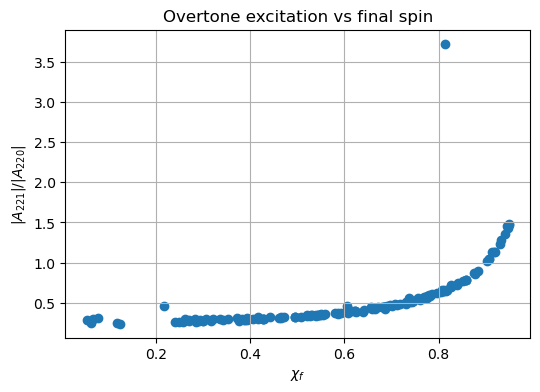

In [ ]:
chi = [r["chi_f"] for r in results]
ratio = [r["ratio"] for r in results]

A220 = [r["A0"] for r in results]
A221 = [r["A1"] for r in results]

plt.figure(figsize=(6,4))

plt.scatter(chi, ratio)

plt.xlabel(r'$\chi_f$')
plt.ylabel(r'$|A_{221}| / |A_{220}|$')

plt.title('Overtone excitation vs final spin')

plt.grid()
plt.show()

plt.figure(figsize=(6,4))

plt.scatter(chi, A220, label=r'$|A_{220}|$', s=20)
plt.scatter(chi, A221, label=r'$|A_{221}|$', s=20)

plt.xlabel(r'$\chi_f$')
plt.ylabel(r'Amplitude')

plt.title('QNM amplitudes vs final spin')

#plt.yscale('log')  
plt.legend()
plt.grid()

plt.show()

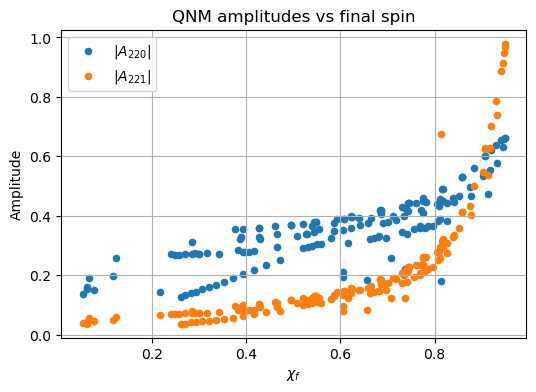

In [5]:
# ---------------------------------------
# Lista de simulaciones (la tuya completa)
# ---------------------------------------
sim_list = [
"SXS:BBH:0004","SXS:BBH:0005","SXS:BBH:0007","SXS:BBH:0013",
"SXS:BBH:0016","SXS:BBH:0019","SXS:BBH:0025","SXS:BBH:0030",
"SXS:BBH:0036","SXS:BBH:0045","SXS:BBH:0046","SXS:BBH:0047",
"SXS:BBH:0056","SXS:BBH:0060","SXS:BBH:0061","SXS:BBH:0063",
"SXS:BBH:0064","SXS:BBH:0065","SXS:BBH:0148","SXS:BBH:0149",
"SXS:BBH:0150","SXS:BBH:0151","SXS:BBH:0152","SXS:BBH:0153",
"SXS:BBH:0154","SXS:BBH:0155","SXS:BBH:0156","SXS:BBH:0157",
"SXS:BBH:0158","SXS:BBH:0159","SXS:BBH:0160","SXS:BBH:0166",
"SXS:BBH:0167","SXS:BBH:0169","SXS:BBH:0170","SXS:BBH:0172",
"SXS:BBH:0174","SXS:BBH:0177","SXS:BBH:0178","SXS:BBH:0180",
"SXS:BBH:0202","SXS:BBH:0203","SXS:BBH:0204","SXS:BBH:0205",
"SXS:BBH:0206","SXS:BBH:0207","SXS:BBH:0306","SXS:BBH:0290",
"SXS:BBH:0291","SXS:BBH:0289","SXS:BBH:0285","SXS:BBH:0261",
"SXS:BBH:0293","SXS:BBH:0280","SXS:BBH:0257","SXS:BBH:0279",
"SXS:BBH:0274","SXS:BBH:0258","SXS:BBH:0248","SXS:BBH:0232",
"SXS:BBH:0229","SXS:BBH:0231","SXS:BBH:0239","SXS:BBH:0252",
"SXS:BBH:0219","SXS:BBH:0211","SXS:BBH:0233","SXS:BBH:0243",
"SXS:BBH:0214","SXS:BBH:0209","SXS:BBH:0226","SXS:BBH:0286",
"SXS:BBH:0253","SXS:BBH:0267","SXS:BBH:0218","SXS:BBH:0238",
"SXS:BBH:0288","SXS:BBH:0287","SXS:BBH:0283","SXS:BBH:0282",
"SXS:BBH:0281","SXS:BBH:0277","SXS:BBH:0284","SXS:BBH:0278",
"SXS:BBH:0256","SXS:BBH:0230","SXS:BBH:0255","SXS:BBH:0276",
"SXS:BBH:0251","SXS:BBH:0250","SXS:BBH:0271","SXS:BBH:0249",
"SXS:BBH:0275","SXS:BBH:0254","SXS:BBH:0269","SXS:BBH:0225",
"SXS:BBH:0270","SXS:BBH:0245","SXS:BBH:0242","SXS:BBH:0223",
"SXS:BBH:0241","SXS:BBH:0240","SXS:BBH:0222","SXS:BBH:0228",
"SXS:BBH:0247","SXS:BBH:0263","SXS:BBH:0266","SXS:BBH:0227",
"SXS:BBH:0221","SXS:BBH:0237","SXS:BBH:0259","SXS:BBH:0574",
"SXS:BBH:0244","SXS:BBH:0217","SXS:BBH:0215","SXS:BBH:0262",
"SXS:BBH:0213","SXS:BBH:0265","SXS:BBH:0264","SXS:BBH:0224",
"SXS:BBH:0236","SXS:BBH:0216","SXS:BBH:0235","SXS:BBH:0220",
"SXS:BBH:0212","SXS:BBH:0303","SXS:BBH:0300","SXS:BBH:0299",
"SXS:BBH:0298","SXS:BBH:0297","SXS:BBH:0296","SXS:BBH:0295",
"SXS:BBH:0292","SXS:BBH:0268","SXS:BBH:0234","SXS:BBH:0273",
"SXS:BBH:0210","SXS:BBH:0260","SXS:BBH:0302","SXS:BBH:0301",
"SXS:BBH:0272","SXS:BBH:0246","SXS:BBH:0610","SXS:BBH:0611",
"SXS:BBH:0612","SXS:BBH:0613","SXS:BBH:0614","SXS:BBH:0615",
"SXS:BBH:0616","SXS:BBH:0617","SXS:BBH:0618","SXS:BBH:0619",
"SXS:BBH:0620","SXS:BBH:0621","SXS:BBH:0622"
]

# ---------------------------------------
# Modos QNM (los tuyos)
# ---------------------------------------
qnms = [(2,2,n,1) for n in range(7)]
spherical_modes = [(2,2)]

# ---------------------------------------
# LOOP
# ---------------------------------------
for sim_name in sim_list:
    try:
        sim = sxs.load(sim_name, extrapolation='N2', ignore_deprecation=True)

        Mf = sim.metadata.remnant_mass
        chif = sim.metadata.remnant_dimensionless_spin
        chif_mag = np.linalg.norm(chif)

        h = qnmfits.utils.sxs_to_scri_WaveformModes(sim.h)
        h22 = h.data[:, h.index(2,2)]

        # shift to peak
        h.t -= h.t[np.argmax(np.abs(h22))]

        # =========================
        # FIT 1: t_peak
        # =========================
        fit_peak = qnmfits.fit(
            data=h,
            chif=chif_mag,
            Mf=Mf,
            qnms=qnms,
            spherical_modes=spherical_modes,
            t0=0.
        )

        # =========================
        # FIT 2: t_peak + 10
        # =========================
        fit_10 = qnmfits.fit(
            data=h,
            chif=chif_mag,
            Mf=Mf,
            qnms=qnms,
            spherical_modes=spherical_modes,
            t0=0.,
            t_ref=10.
        )

        amps = fit_10["amplitudes"]

        print(f"\n{sim_name} (chi_f = {chif_mag:.4f})")
        print("Mismatch:", fit_10["mismatch"])

        for mode in qnms:
            A = amps[mode]
            print(f"{mode}: |A| = {abs(A):.6e}, Arg(A) = {np.angle(A):.6f}")

    except Exception as e:
        print(f"{sim_name}: ERROR ({e})")


SXS:BBH:0004 (chi_f = 0.6082)
Mismatch: 1.4146407582016352e-05
(2, 2, 0, 1): |A| = 3.932609e-01, Arg(A) = 1.416137
(2, 2, 1, 1): |A| = 2.452419e-01, Arg(A) = -0.613453
(2, 2, 2, 1): |A| = 9.532495e-02, Arg(A) = 3.134383
(2, 2, 3, 1): |A| = 2.584495e-02, Arg(A) = 0.301953
(2, 2, 4, 1): |A| = 4.566710e-03, Arg(A) = -2.671699
(2, 2, 5, 1): |A| = 4.504160e-04, Arg(A) = 0.493657
(2, 2, 6, 1): |A| = 1.640164e-05, Arg(A) = -2.766677

SXS:BBH:0005 (chi_f = 0.7607)
Mismatch: 4.777484981299818e-05
(2, 2, 0, 1): |A| = 4.363133e-01, Arg(A) = 1.047965
(2, 2, 1, 1): |A| = 4.169685e-01, Arg(A) = -0.907861
(2, 2, 2, 1): |A| = 2.299856e-01, Arg(A) = 2.941633
(2, 2, 3, 1): |A| = 8.353068e-02, Arg(A) = 0.217377
(2, 2, 4, 1): |A| = 2.008062e-02, Arg(A) = -2.674232
(2, 2, 5, 1): |A| = 2.870888e-03, Arg(A) = 0.463101
(2, 2, 6, 1): |A| = 1.285110e-04, Arg(A) = -2.983096

SXS:BBH:0007 (chi_f = 0.6641)
Mismatch: 4.636750662756484e-06
(2, 2, 0, 1): |A| = 3.967315e-01, Arg(A) = 1.964877
(2, 2, 1, 1): |A| = 2.79

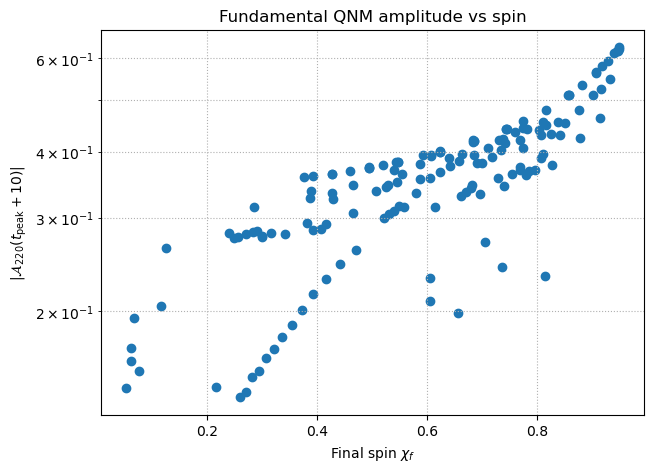

In [ ]:
# ---------------------------------------
# Arrays donde guardamos resultados
# ---------------------------------------
chi_vals = []
A220_vals = []

for sim_name in sim_list:
    try:
        sim = sxs.load(sim_name, extrapolation='N2', ignore_deprecation=True)

        Mf = sim.metadata.remnant_mass
        chif = sim.metadata.remnant_dimensionless_spin
        chif_mag = np.linalg.norm(chif)

        h = qnmfits.utils.sxs_to_scri_WaveformModes(sim.h)
        h22 = h.data[:, h.index(2,2)]

        # shift to peak
        h.t -= h.t[np.argmax(np.abs(h22))]

        # Fit en t_peak + 10
        fit_10 = qnmfits.fit(
            data=h,
            chif=chif_mag,
            Mf=Mf,
            qnms=qnms,
            spherical_modes=spherical_modes,
            t0=0.,
            t_ref=10.
        )

        A = fit_10["amplitudes"][(2,2,0,1)]

        chi_vals.append(chif_mag)
        A220_vals.append(abs(A))

    except:
        continue

# ---------------------------------------
# Plot
# ---------------------------------------
fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(chi_vals, A220_vals)

ax.set_yscale('log')

ax.set_xlabel(r'Final spin $\chi_f$')
ax.set_ylabel(r'$|\mathcal{A}_{220}(t_{\mathrm{peak}}+10)|$')

ax.set_title('Fundamental QNM amplitude vs spin')

ax.grid(True, which="both", ls=":")

plt.show()

# other

SXS:BBH:0004: q=1.00, chi_f=0.6082
SXS:BBH:0005: q=1.00, chi_f=0.7607
SXS:BBH:0007: q=1.50, chi_f=0.6641
SXS:BBH:0013: q=1.50, chi_f=0.7814
SXS:BBH:0016: q=1.50, chi_f=0.5403
SXS:BBH:0019: q=1.50, chi_f=0.5868
SXS:BBH:0025: q=1.50, chi_f=0.7384
SXS:BBH:0030: q=3.00, chi_f=0.5406
SXS:BBH:0036: q=3.00, chi_f=0.3163
SXS:BBH:0045: q=3.00, chi_f=0.7410
SXS:BBH:0046: q=3.00, chi_f=0.2993
SXS:BBH:0047: q=3.00, chi_f=0.7686
SXS:BBH:0056: q=5.00, chi_f=0.4166
SXS:BBH:0060: q=5.00, chi_f=0.1166
SXS:BBH:0061: q=5.00, chi_f=0.7065
SXS:BBH:0063: q=8.00, chi_f=0.3067
SXS:BBH:0064: q=8.00, chi_f=0.0526
SXS:BBH:0065: q=8.00, chi_f=0.6574
SXS:BBH:0148: q=1.00, chi_f=0.5478
SXS:BBH:0149: q=1.00, chi_f=0.6242
SXS:BBH:0150: q=1.00, chi_f=0.7464
SXS:BBH:0151: q=1.00, chi_f=0.4942
SXS:BBH:0152: q=1.00, chi_f=0.8578
SXS:BBH:0153: q=1.00, chi_f=0.9191
SXS:BBH:0154: q=1.00, chi_f=0.4269
SXS:BBH:0155: q=1.00, chi_f=0.9075
SXS:BBH:0156: q=1.00, chi_f=0.3757
SXS:BBH:0157: q=1.00, chi_f=0.9409
SXS:BBH:0158: q=1.00

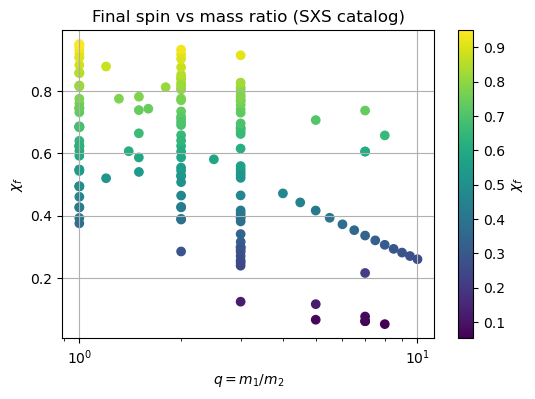

In [13]:
import sxs
import numpy as np
import matplotlib.pyplot as plt

chi_list = []
q_list = []

for sim_name in sim_list:
    try:
        sim = sxs.load(sim_name, ignore_deprecation=True)

        # --- spin final ---
        chif = sim.metadata.remnant_dimensionless_spin
        chif_mag = np.linalg.norm(chif)

        # --- mass ratio ---
        m1 = sim.metadata.reference_mass1
        m2 = sim.metadata.reference_mass2
        q = m1 / m2 if m1 >= m2 else m2 / m1   # asegurar q >= 1

        chi_list.append(chif_mag)
        q_list.append(q)

        print(f"{sim_name}: q={q:.2f}, chi_f={chif_mag:.4f}")

    except Exception as e:
        print(f"{sim_name}: ERROR ({e})")

# =========================
# PLOT
# =========================

plt.figure(figsize=(6,4))

plt.scatter(q_list, chi_list, c=chi_list, cmap='viridis')
plt.colorbar(label=r'$\chi_f$')

plt.xscale('log')

plt.xlabel(r'$q = m_1/m_2$')
plt.ylabel(r'$\chi_f$')

plt.title('Final spin vs mass ratio (SXS catalog)')
plt.grid()

plt.show()

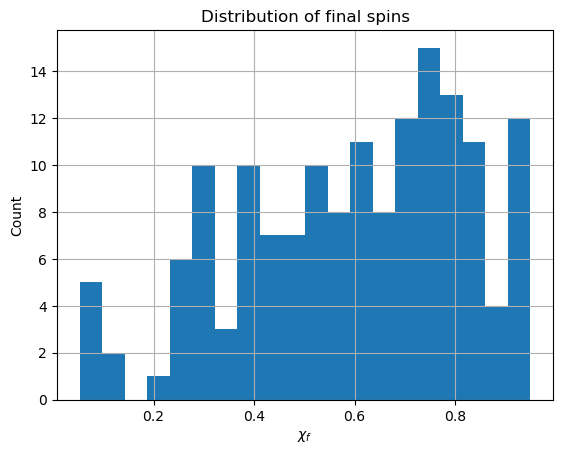

In [14]:
plt.hist(chi_list, bins=20)

plt.xlabel(r'$\chi_f$')
plt.ylabel('Count')
plt.title('Distribution of final spins')

plt.grid()
plt.show()

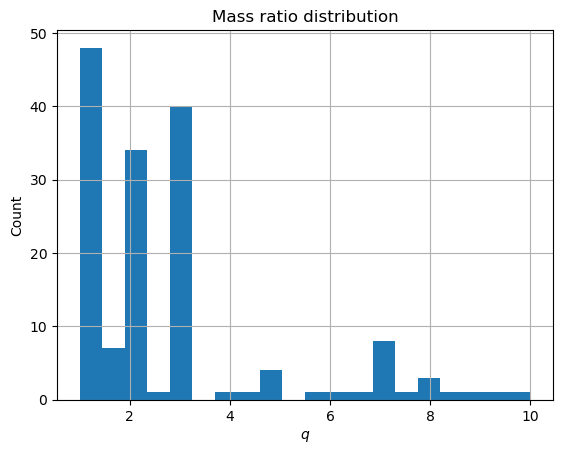

In [15]:
plt.hist(q_list, bins=20)

plt.xlabel(r'$q$')
plt.ylabel('Count')
plt.title('Mass ratio distribution')

plt.grid()
plt.show()

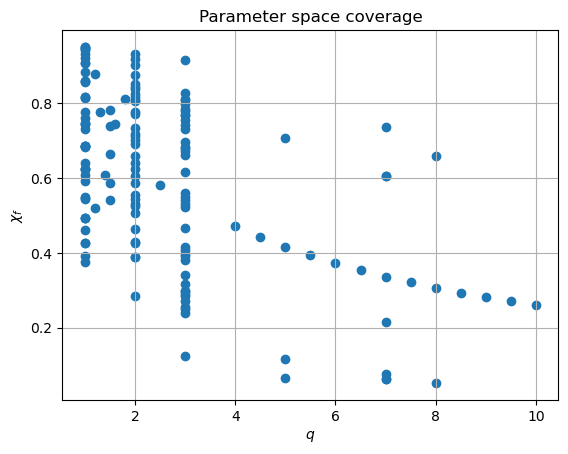

In [16]:
plt.scatter(q_list, chi_list)

plt.xlabel(r'$q$')
plt.ylabel(r'$\chi_f$')
plt.title('Parameter space coverage')

plt.grid()
plt.show()

In [17]:
for sim, q, chi in zip(sim_list, q_list, chi_list):
    if chi < 0.1 or chi > 0.95:
        print(sim, q, chi)

SXS:BBH:0064 8.003464639356801 0.05257841838510002
SXS:BBH:0205 7.001089078006648 0.06195132534032625
SXS:BBH:0206 7.001211829508203 0.06194359514191458
SXS:BBH:0207 6.999859788105564 0.07695373823630955
SXS:BBH:0620 5.000947177195083 0.06665256004273093


In [18]:
print("Low spin (<0.3):", np.sum(np.array(chi_list) < 0.3))
print("Mid spin (0.3–0.7):", np.sum((np.array(chi_list) >= 0.3) & (np.array(chi_list) < 0.7)))
print("High spin (>0.7):", np.sum(np.array(chi_list) >= 0.7))

Low spin (<0.3): 21
Mid spin (0.3–0.7): 75
High spin (>0.7): 59


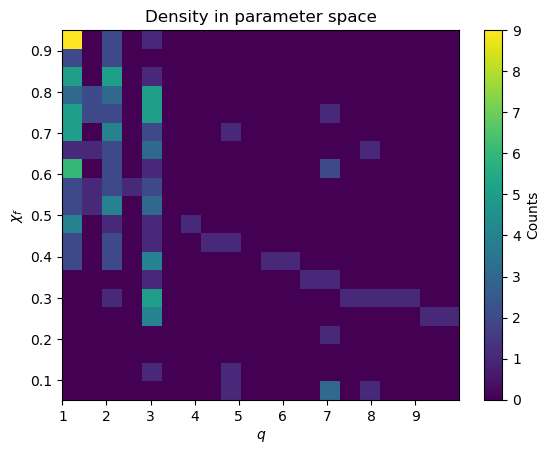

In [19]:
plt.hist2d(q_list, chi_list, bins=20)

plt.xlabel(r'$q$')
plt.ylabel(r'$\chi_f$')
plt.title('Density in parameter space')

plt.colorbar(label='Counts')
plt.show()

In [20]:
data = sorted(zip(sim_list, q_list, chi_list), key=lambda x: x[2])

for sim, q, chi in data:
    print(f"{sim}: q={q:.2f}, chi_f={chi:.4f}")

SXS:BBH:0064: q=8.00, chi_f=0.0526
SXS:BBH:0206: q=7.00, chi_f=0.0619
SXS:BBH:0205: q=7.00, chi_f=0.0620
SXS:BBH:0620: q=5.00, chi_f=0.0667
SXS:BBH:0207: q=7.00, chi_f=0.0770
SXS:BBH:0060: q=5.00, chi_f=0.1166
SXS:BBH:0260: q=3.00, chi_f=0.1245
SXS:BBH:0621: q=7.00, chi_f=0.2165
SXS:BBH:0261: q=3.00, chi_f=0.2398
SXS:BBH:0264: q=3.00, chi_f=0.2495
SXS:BBH:0265: q=3.00, chi_f=0.2566
SXS:BBH:0303: q=10.00, chi_f=0.2606
SXS:BBH:0262: q=3.00, chi_f=0.2706
SXS:BBH:0302: q=9.50, chi_f=0.2708
SXS:BBH:0301: q=9.00, chi_f=0.2819
SXS:BBH:0266: q=3.00, chi_f=0.2844
SXS:BBH:0234: q=2.00, chi_f=0.2854
SXS:BBH:0263: q=3.00, chi_f=0.2912
SXS:BBH:0300: q=8.50, chi_f=0.2937
SXS:BBH:0267: q=3.00, chi_f=0.2992
SXS:BBH:0046: q=3.00, chi_f=0.2993
SXS:BBH:0063: q=8.00, chi_f=0.3067
SXS:BBH:0036: q=3.00, chi_f=0.3163
SXS:BBH:0299: q=7.50, chi_f=0.3210
SXS:BBH:0298: q=7.00, chi_f=0.3365
SXS:BBH:0268: q=3.00, chi_f=0.3412
SXS:BBH:0297: q=6.50, chi_f=0.3536
SXS:BBH:0166: q=6.00, chi_f=0.3725
SXS:BBH:0156: q=1.0

## Fit for the remnant mass and spin

The `qnmfits.fit_mass_spin()` function additionally treats the remnant mass and spin as free parameters. These are fitted for via `scipy.optimize.minimize`, where the mismatch between data and ringdown model is minimized. Internally the `qnmfits.fit()` function is being called to fit the complex QNM amplitudes via least squares.

In [13]:
best_fit = qnmfits.fit_mass_spin(
    data=h,
    qnms=qnms,
    spherical_modes=spherical_modes,
    t0=t0,
)

# The result is a dictionary as before, but now with keys for mass and spin
best_fit['mass'], best_fit['spin']

(0.9518025109390147, 0.6923427225567864)

In [14]:
# We can calculated a "distance" between the true mass and spin and the 
# best-fit values, as in https://arxiv.org/abs/1903.08284
np.sqrt((chif_mag - best_fit['spin'])**2 + (Mf - best_fit['mass'])**2)

0.00034557498822060904

To visualize this minimization we can grid over mass and spin, and plot the mismatch as a heatmap.

100%|██████████| 2500/2500 [00:18<00:00, 137.91it/s]


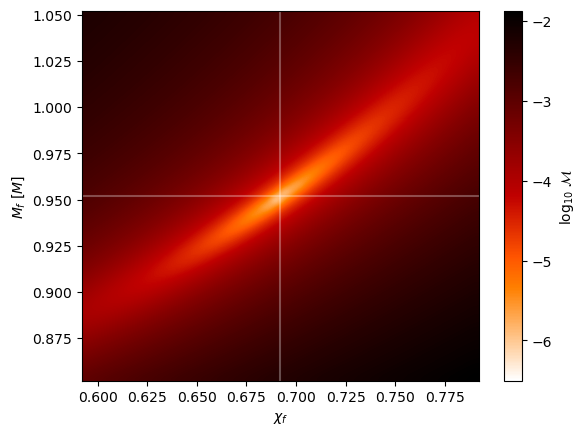

In [15]:
from tqdm import tqdm

Mf_minmax = [Mf-0.1, Mf+0.1]
chif_minmax = [chif_mag-0.1, chif_mag+0.1]
res = 50

# Create the mass and spin arrays
Mf_array = np.linspace(Mf_minmax[0], Mf_minmax[1], res)
chif_array = np.linspace(chif_minmax[0], chif_minmax[1], res)

# List to store the mismatch from each choice of M and chi
mm_list = []

# Cycle through each combination of mass and spin, calculating the
# mismatch for each. Use a single loop for the progress bar.
for i in tqdm(range(len(Mf_array)*len(chif_array))):

    Mf_i = Mf_array[int(i/len(Mf_array))]
    chif_i = chif_array[i%len(chif_array)]

    best_fit = qnmfits.fit(
        data=h,
        chif=chif_i, 
        Mf=Mf_i, 
        qnms=qnms,
        spherical_modes=spherical_modes,
        t0=t0
    )
    mm_list.append(best_fit['mismatch'])

# Convert the list of mismatches to a grid
mm_grid = np.reshape(np.array(mm_list), (len(Mf_array), len(chif_array)))

fig, ax = plt.subplots()

# Plot heatmap
im = ax.imshow(
    np.log10(mm_grid), 
    extent=[*chif_minmax, *Mf_minmax],
    aspect='auto',
    origin='lower',
    interpolation='bicubic',
    cmap='gist_heat_r')

# Indicate true values
ax.axhline(Mf, color='w', alpha=0.3)
ax.axvline(chif_mag, color='w', alpha=0.3)

# Color bar
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel('$\mathrm{log}_{10}\ \mathcal{M}$')

ax.set_xlabel('$\chi_f$')
ax.set_ylabel('$M_f\ [M]$');

## Perform fits for a range of ringdown start times

We can create the common mismatch curves in the following way:

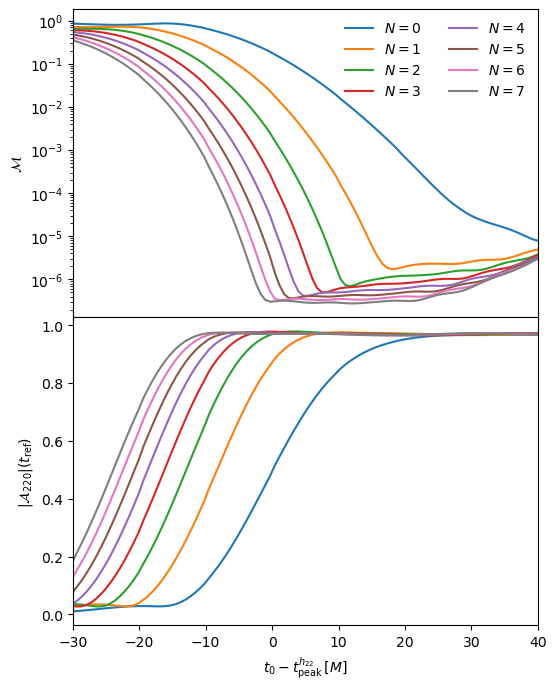

In [16]:
# Now perform fits with different numbers of overtones, from N=0 to N=7
qnm_list = [[(2,2,n,1) for n in range(N)] for N in range(1,7+2)]
spherical_modes = [(2,2)]

# The start times to use
t0_array = np.linspace(-30, 40, 100)

# We can specify a reference time for when the QNM amplitudes are defined. This
# is useful for investigating mode stability.
t_ref = 0

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(6,8), sharex=True)
fig.subplots_adjust(hspace=0)

# We will store the fundamental mode amplitudes for each fit to investigate
# mode stability
A220_dict = {}

for N, qnms in enumerate(qnm_list):

    # Store the fundamental mode amplitude for each start time, and the 
    # mismatch
    A220_dict[N] = []
    mm_list = []

    for t0 in t0_array:
        best_fit = qnmfits.fit(
            data=h,
            chif=chif_mag,
            Mf=Mf,
            qnms=qnms,
            spherical_modes=spherical_modes,
            t0=t0,
            t_ref=t_ref
        )
        mm_list.append(best_fit['mismatch'])
        A220_dict[N].append(abs(best_fit['amplitudes'][2,2,0,1]))
        
    # Add to figure
    axs[0].semilogy(t0_array, mm_list, label=f'$N = {N}$')
    axs[1].plot(t0_array, A220_dict[N])
    
# Plot limits and labels
axs[0].set_xlim(t0_array[0], t0_array[-1])
axs[1].set_xlabel('$t_0 - t^{h_{22}}_\mathrm{peak}\, [M]$')
axs[0].set_ylabel('$\mathcal{M}$')
axs[1].set_ylabel('$|\mathcal{A}_{220}|(t_\mathrm{ref})$')

axs[0].legend(ncol=2, frameon=False);

## Multimode fits

In [17]:
qnms = [(ell,2,n,1) for ell in range(2,3+1) for n in range(7+1)]

# Simply include the additional spherical modes in the list, and the code takes
# care of the mode mixing
spherical_modes = [(2,2),(3,2)]

t0 = 0

best_fit = qnmfits.fit(
    data=h,
    chif=chif_mag, 
    Mf=Mf,
    qnms=qnms,
    spherical_modes=spherical_modes,
    t0=t0
)

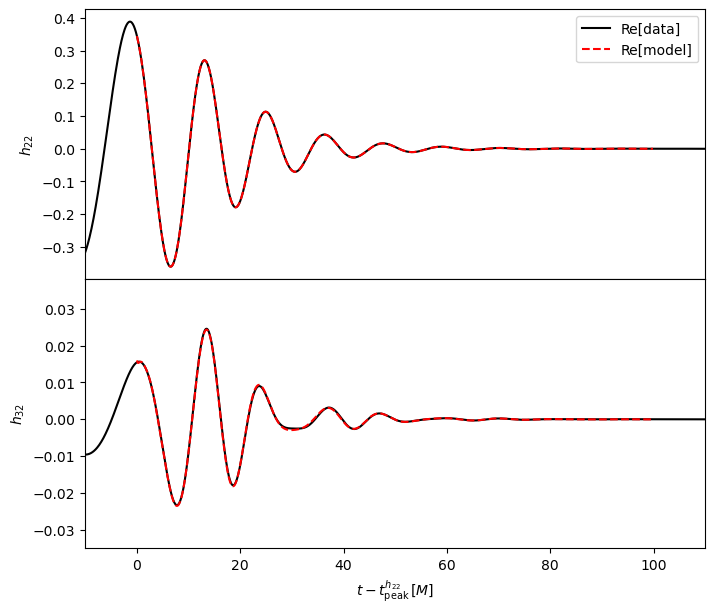

In [18]:
# Plot the best-fit model against the data

h32 = h.data[:,h.index(3,2)]

h_best_fit = best_fit['model']
h22_best_fit = h_best_fit.data[:, h_best_fit.index(2,2)]
h32_best_fit = h_best_fit.data[:, h_best_fit.index(3,2)]

fig, axs = plt.subplots(2, figsize=(8,7), sharex=True)
fig.subplots_adjust(hspace=0)

axs[0].plot(h.t, np.real(h22), c='k', label='Re[data]')
axs[0].plot(
    h_best_fit.t, 
    np.real(h22_best_fit), 
    c='r', 
    ls='--',
    label='Re[model]'
)

axs[1].plot(h.t, np.real(h32), c='k')
axs[1].plot(
    h_best_fit.t, 
    np.real(h32_best_fit), 
    c='r', 
    ls='--',
)

axs[1].set_xlabel('$t - t_\mathrm{peak}^{h_{22}}\, [M]$')
axs[0].set_ylabel('$h_{22}$')
axs[1].set_ylabel('$h_{32}$')

axs[0].legend()

axs[0].set_xlim(-10, 110);

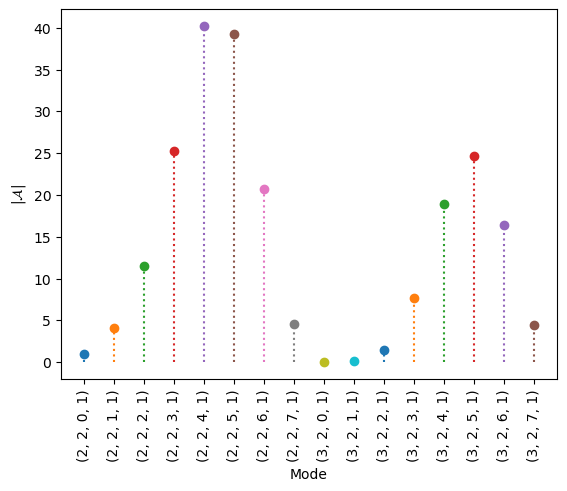

In [19]:
# Plot the best-fit mode amplitudes

amplitudes = [abs(best_fit['amplitudes'][label]) for label in qnms]
labels = [str(label) for label in qnms]

# x-axis values, useful for plotting
x = np.arange(len(amplitudes))
    
fig, ax = plt.subplots()

for i in range(len(amplitudes)):
    ax.plot(
        [x[i],x[i]], [0,amplitudes[i]], color=f'C{i}', marker='o', 
        markevery=(1,2), linestyle=':')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.tick_params(axis='x', rotation=90)

ax.set_xlabel('Mode')
ax.set_ylabel('$|\mathcal{A}|$');

In [20]:
best_fit['mismatch']

1.278614024657898e-06

## Beyond $n = 7$

Additional QNM data can be downloaded with 

```python
import qnmfits
qnmfits.download_cook_data()
```

This downloads the $n = 8$ and $n=9$ QNM data from https://zenodo.org/records/10093311, as computed by Cook & Zalutskiy.

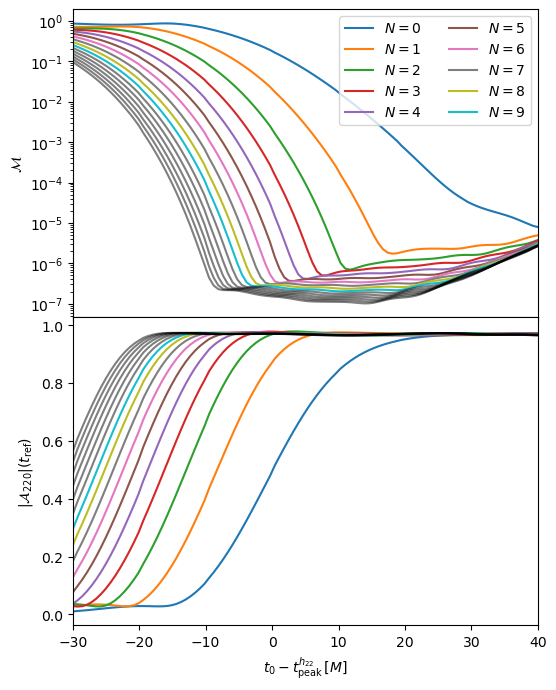

In [21]:
# Now perform fits with overtones up to N=15
qnm_list = [[(2,2,n,1) for n in range(N)] for N in range(1,15+2)]
spherical_modes = [(2,2)]

# The start times to use
t0_array = np.linspace(-30, 40, 100)
t_ref = 0

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(6,8), sharex=True)
fig.subplots_adjust(hspace=0)

# We will store the fundamental mode amplitudes for each fit to investigate
# mode stability
A220_dict = {}

for N, qnms in enumerate(qnm_list):

    # Store the fundamental mode amplitude for each start time, and the 
    # mismatch
    A220_dict[N] = []
    mm_list = []

    for t0 in t0_array:
        best_fit = qnmfits.fit(
            data=h,
            chif=chif_mag,
            Mf=Mf,
            qnms=qnms,
            spherical_modes=spherical_modes,
            t0=t0,
            t_ref=t_ref
        )
        mm_list.append(best_fit['mismatch'])
        A220_dict[N].append(abs(best_fit['amplitudes'][2,2,0,1]))
        
    # Add to figure

    if N > 9:
        c = 'k'
        alpha = 0.5
        label = None
    else:
        c = f'C{N}'
        alpha = 1
        label = f'$N = {N}$'

    axs[0].semilogy(t0_array, mm_list, label=label, c=c, alpha=alpha)
    axs[1].plot(t0_array, A220_dict[N], c=c, alpha=alpha)
    
# Plot limits and labels
axs[0].set_xlim(t0_array[0], t0_array[-1])
axs[1].set_xlabel('$t_0 - t^{h_{22}}_\mathrm{peak}\, [M]$')
axs[0].set_ylabel('$\mathcal{M}$')
axs[1].set_ylabel('$|\mathcal{A}_{220}|(t_\mathrm{ref})$')

axs[0].legend(ncol=2);